## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
train = pd.read_csv("train.csv")
train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
test = pd.read_csv("test.csv")
test.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


## Feature Engineering

Drop columns that aren't needed

In [4]:
train = train.drop(columns=["Unnamed: 0","id"])
test = test.drop(columns=["Unnamed: 0","id"])

Combine the train and test sets

In [5]:
train["code"] = "train"
test["code"] = "test"

In [6]:
df = pd.concat([train,test],axis=0)
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,code
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


Check if there are missing values

In [7]:
df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
code                                   0
dtype: int64

In [8]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].mean())

Split into train and test sets

In [91]:
train = df[df["code"] == "train"]
train = train.drop(columns="code")

In [92]:
test = df[df["code"] == "test"]
test = test.drop(columns="code")

Define X and y variables and convert string to numerical variables with dummy variables

In [93]:
X_train = pd.get_dummies(train.drop(columns="satisfaction"),drop_first=True)
y_train = train["satisfaction"]

In [94]:
X_test = pd.get_dummies(test.drop(columns="satisfaction"),drop_first=True)
y_test = test["satisfaction"]

## Data Visualization

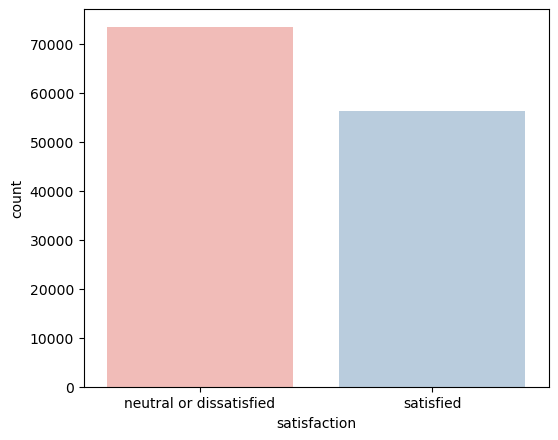

In [95]:
plt.figure(figsize=(6,5),dpi=100)
sns.countplot(data=df,x="satisfaction",palette="Pastel1");

## Decision Tree

Scalling the Data

In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()

In [98]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

Cross-validation using GridSearchCV

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [17]:
decision_tree_model = DecisionTreeClassifier(random_state=101)

In [20]:
decision_tree_params = {"criterion":["gini","entropy"],
                        "max_features":["auto","sqrt","log2"]}

In [21]:
decision_tree_grid = GridSearchCV(decision_tree_model,decision_tree_params)

In [22]:
decision_tree_grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=101),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': ['auto', 'sqrt', 'log2']})

In [23]:
# {'criterion': 'entropy', 'max_features': 'auto'}
decision_tree_grid.best_params_

{'criterion': 'entropy', 'max_features': 'auto'}

Create the best model based on cross-validation

In [135]:
decision_tree_best_model = DecisionTreeClassifier(criterion='entropy',max_features='auto')

In [136]:
decision_tree_best_model.fit(scaled_X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_features='auto')

In [137]:
decision_tree_preds = decision_tree_best_model.predict(scaled_X_test)

Evaluation

In [138]:
from sklearn.metrics import classification_report,plot_confusion_matrix,accuracy_score

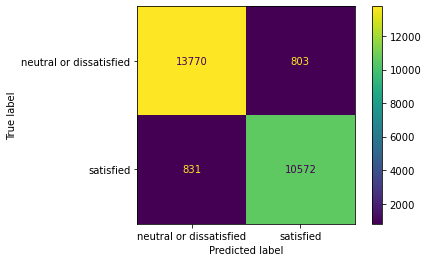

In [139]:
plot_confusion_matrix(decision_tree_best_model,scaled_X_test,y_test);

In [140]:
print(classification_report(y_test,decision_tree_preds))

                         precision    recall  f1-score   support

neutral or dissatisfied       0.94      0.94      0.94     14573
              satisfied       0.93      0.93      0.93     11403

               accuracy                           0.94     25976
              macro avg       0.94      0.94      0.94     25976
           weighted avg       0.94      0.94      0.94     25976



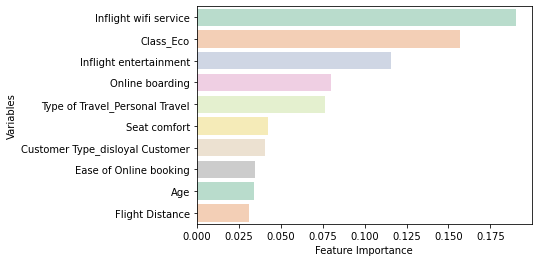

In [141]:
feature = pd.DataFrame({"Variables":X_train.columns,"Feature Importance":decision_tree_best_model.feature_importances_})
feature = feature.sort_values(['Feature Importance'],ascending=False).head(10)

sns.barplot(data=feature,x="Feature Importance",y="Variables",palette="Pastel2");

Visualize the Tree

In [142]:
from sklearn.tree import plot_tree

In [143]:
# This process may take a while

# plt.figure(figsize=(12,8),dpi=150)
# plot_tree(decision_tree_grid,filled=True,feature_names=X_train.columns);

## Random Forest

Cross-validation using GridSearchCV

In [119]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
ramdom_forest_model = RandomForestClassifier(random_state=101)

In [34]:
ramdom_forest_params = {"criterion":["gini","entropy"],
                        "max_features":["auto","sqrt","log2"]}

In [35]:
ramdom_forest_grid = GridSearchCV(ramdom_forest_model,ramdom_forest_params)

In [36]:
ramdom_forest_grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=101),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': ['auto', 'sqrt', 'log2']})

In [38]:
# {'criterion': 'entropy', 'max_features': 'auto'}
ramdom_forest_grid.best_params_

{'criterion': 'entropy', 'max_features': 'auto'}

Create the best model based on cross-validation

In [144]:
ramdom_forest_best_model = RandomForestClassifier(criterion='entropy',max_features='auto')

In [145]:
ramdom_forest_best_model.fit(scaled_X_train,y_train)

RandomForestClassifier(criterion='entropy')

In [146]:
ramdom_forest_preds = ramdom_forest_best_model.predict(scaled_X_test)

Evaluation

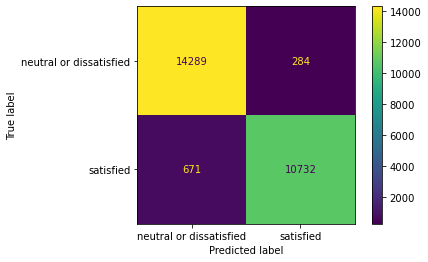

In [147]:
plot_confusion_matrix(ramdom_forest_best_model,scaled_X_test,y_test);

In [148]:
print(classification_report(y_test,ramdom_forest_preds))

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14573
              satisfied       0.97      0.94      0.96     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



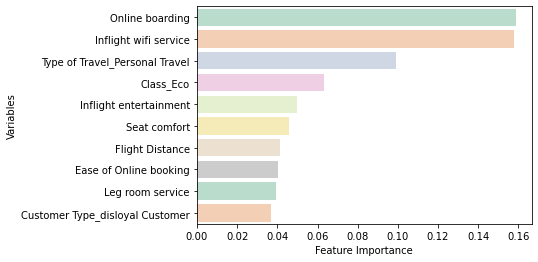

In [149]:
feature = pd.DataFrame({"Variables":X_train.columns,"Feature Importance":ramdom_forest_best_model.feature_importances_})
feature = feature.sort_values(['Feature Importance'],ascending=False).head(10)

sns.barplot(data=feature,x="Feature Importance",y="Variables",palette="Pastel2");

## SVM

Cross-validation using GridSearchCV

In [130]:
from sklearn.svm import SVC

In [19]:
svm_model = SVC()

In [20]:
svm_params = {'C':[0.01,0.1,1],'kernel':['linear','rbf']}

In [21]:
svm_grid = GridSearchCV(svm_model,svm_params)

In [22]:
svm_grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']})

In [24]:
# {'C': 1, 'kernel': 'rbf'}
svm_grid.best_params_

{'C': 1, 'kernel': 'rbf'}

Create the best model based on cross-validation

In [132]:
svm_best_model = SVC(C=1,kernel="rbf")

In [133]:
svm_best_model.fit(scaled_X_train,y_train)

SVC(C=1)

In [134]:
svm_preds = svm_best_model.predict(scaled_X_test)

Evaluation

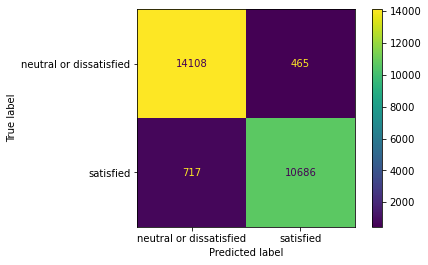

In [151]:
plot_confusion_matrix(svm_best_model,scaled_X_test,y_test);

In [152]:
print(classification_report(y_test,svm_preds))

                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.97      0.96     14573
              satisfied       0.96      0.94      0.95     11403

               accuracy                           0.95     25976
              macro avg       0.95      0.95      0.95     25976
           weighted avg       0.95      0.95      0.95     25976



## KNN

Choose K value using Elbow method

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [32]:
test_error_rates = []

for k in range(1,21):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train) 
   
    y_pred_test = knn_model.predict(scaled_X_test)
    
    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

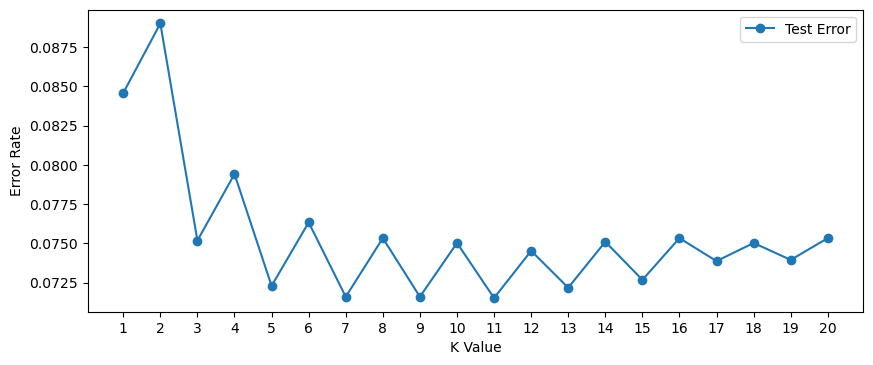

In [33]:
plt.figure(figsize=(10,4),dpi=100)
plt.plot(range(1,21),test_error_rates,label='Test Error',marker="o")
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")
plt.xticks(np.arange(1,21,1))
plt.show()

Choose K value using cross-validation (GridSearchCV)

In [34]:
knn_model = KNeighborsClassifier()

In [35]:
knn_params = {"n_neighbors":np.arange(1,21)}

In [36]:
knn_grid = GridSearchCV(knn_model,knn_params)

In [37]:
knn_grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])})

In [38]:
# {'n_neighbors': 7}
knn_grid.best_params_

{'n_neighbors': 7}

Create the best model based on cross-validation

In [156]:
knn_best_model = KNeighborsClassifier(n_neighbors=7)

In [157]:
knn_best_model.fit(scaled_X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [158]:
knn_preds = knn_best_model.predict(scaled_X_test)

Evaluation

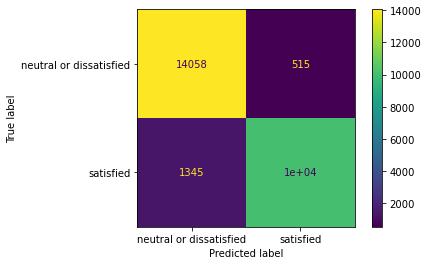

In [159]:
plot_confusion_matrix(knn_best_model,scaled_X_test,y_test);

In [160]:
print(classification_report(y_test,knn_preds))

                         precision    recall  f1-score   support

neutral or dissatisfied       0.91      0.96      0.94     14573
              satisfied       0.95      0.88      0.92     11403

               accuracy                           0.93     25976
              macro avg       0.93      0.92      0.93     25976
           weighted avg       0.93      0.93      0.93     25976



## Comparison of All Models

In [167]:
accuracy = [accuracy_score(y_test,decision_tree_preds),accuracy_score(y_test,ramdom_forest_preds),
            accuracy_score(y_test,svm_preds),accuracy_score(y_test,knn_preds)]

In [169]:
models = ["Decision Tree","Random Forest","SVM","KNN"]

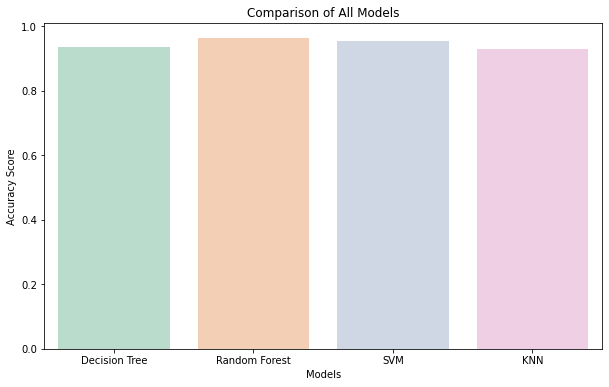

In [183]:
plt.figure(figsize=(10,6))
sns.barplot(x=models,y=accuracy,palette="Pastel2")
plt.title("Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.show()